### Import Required Libraries

In [45]:
pip install pandas numpy matplotlib seaborn scikit-learn jupyter

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### Load Dataset

In [47]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

### Display Dataset Overview

In [48]:
print("=" * 60)
print("CALIFORNIA HOUSING DATASET OVERVIEW")
print("=" * 60)

# ------------------------------------------------------------
# First Five Rows
# ------------------------------------------------------------

print("\n First Five Rows of Dataset")
print("-" * 60)

display(df.head())


# ------------------------------------------------------------
# Dataset Shape
# ------------------------------------------------------------

print("\n Dataset Shape")
print("-" * 60)

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")


# ------------------------------------------------------------
# Column Names
# ------------------------------------------------------------

print("\n Column Names")
print("-" * 60)

for column in df.columns:
    print(column)


# ------------------------------------------------------------
# Dataset Information
# ------------------------------------------------------------

print("\n Dataset Information")
print("-" * 60)

df.info()


# ------------------------------------------------------------
# Statistical Summary
# ------------------------------------------------------------

print("\n Statistical Summary")
print("-" * 60)

display(df.describe())


CALIFORNIA HOUSING DATASET OVERVIEW

 First Five Rows of Dataset
------------------------------------------------------------


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



 Dataset Shape
------------------------------------------------------------
Number of Rows    : 20640
Number of Columns : 9

 Column Names
------------------------------------------------------------
MedInc
HouseAge
AveRooms
AveBedrms
Population
AveOccup
Latitude
Longitude
MedHouseVal

 Dataset Information
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

 Statistical Summar

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Check Missing Values

In [49]:
# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

display(missing_df)

MISSING VALUES


,Missing Values,Percentage
MedInc,0,0.0
HouseAge,0,0.0
AveRooms,0,0.0
AveBedrms,0,0.0
Population,0,0.0
AveOccup,0,0.0
Latitude,0,0.0
Longitude,0,0.0
MedHouseVal,0,0.0


### Missing Value Function

In [50]:
# ============================================================
# FUNCTION FOR HANDLING MISSING VALUES
# ============================================================
# Logic:
# Symmetric Numerical Data  -> Mean
# Skewed Numerical Data     -> Median
# Categorical Data          -> Mode
# ============================================================

def handle_missing_values(dataframe):
    
    # Numerical Columns
    numerical_columns = dataframe.select_dtypes(
        include=np.number
    ).columns

    # Categorical Columns
    categorical_columns = dataframe.select_dtypes(
        exclude=np.number
    ).columns

    
    print("=" * 60)
    print("HANDLING NUMERICAL MISSING VALUES")
    print("=" * 60)

    
    for column in numerical_columns:

        missing_count = dataframe[column].isnull().sum()

        if missing_count > 0:

            skewness = dataframe[column].skew()

            print(f"\nColumn: {column}")
            print(f"Missing Values: {missing_count}")
            print(f"Skewness: {skewness}")

            
            # If data is symmetric
            if -0.5 < skewness < 0.5:

                mean_value = dataframe[column].mean()

                dataframe[column] = dataframe[column].fillna(
                    mean_value
                )

                print("Filled using MEAN")

            
            # If data is skewed
            else:

                median_value = dataframe[column].median()

                dataframe[column] = dataframe[column].fillna(
                    median_value
                )

                print("Filled using MEDIAN")


    print("\n" + "=" * 60)
    print("HANDLING CATEGORICAL MISSING VALUES")
    print("=" * 60)

    
    for column in categorical_columns:

        missing_count = dataframe[column].isnull().sum()

        if missing_count > 0:

            mode_value = dataframe[column].mode()[0]

            dataframe[column] = dataframe[column].fillna(
                mode_value
            )

            print(f"{column} filled using MODE")

    
    return dataframe

### Apply Missing Value Function

In [51]:
# ============================================================
# APPLY MISSING VALUE FUNCTION
# ============================================================

df = handle_missing_values(df)

HANDLING NUMERICAL MISSING VALUES

HANDLING CATEGORICAL MISSING VALUES


### Verify Missing Values Again

In [52]:
# ============================================================
# VERIFY MISSING VALUES AGAIN
# ============================================================

print("\n" + "=" * 60)
print("MISSING VALUES AFTER HANDLING")
print("=" * 60)

display(df.isnull().sum())


MISSING VALUES AFTER HANDLING


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [53]:
### Check Duplicate Values

In [54]:
# ============================================================
# DUPLICATE VALUE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("DUPLICATE VALUE ANALYSIS")
print("=" * 60)

duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_count}")


DUPLICATE VALUE ANALYSIS
Duplicate Rows : 0


### Check Data Types

In [55]:
# ============================================================
# DATA TYPES
# ============================================================

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)

display(df.dtypes)


DATA TYPES


MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

## Univariate Analysis

### Distribution Plot

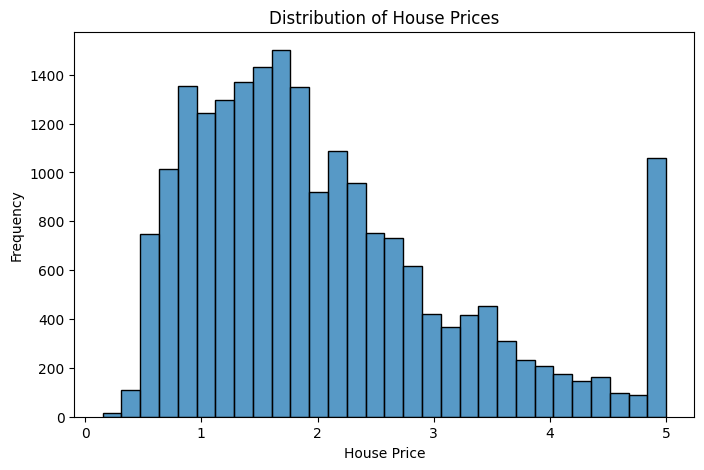

In [56]:
plt.figure(figsize=(8,5))

sns.histplot(df['MedHouseVal'], bins=30)

plt.title("Distribution of House Prices")

plt.xlabel("House Price")

plt.ylabel("Frequency")

plt.show()

### Boxplot for Outlier Detection

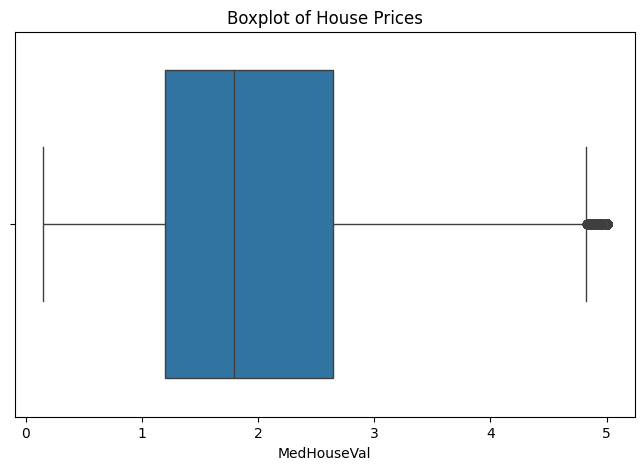

In [57]:
# ============================================================
# OUTLIER DETECTION
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['MedHouseVal']
)

plt.title("Boxplot of House Prices")

plt.show()

### Correlation Analysis

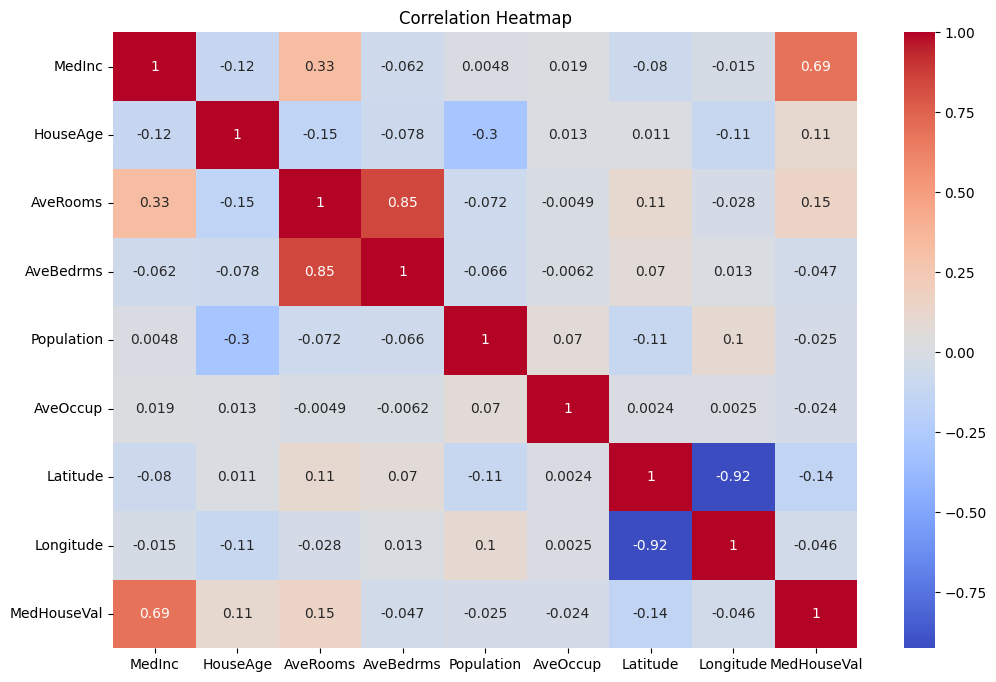

In [58]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

## Bivariate Analysis

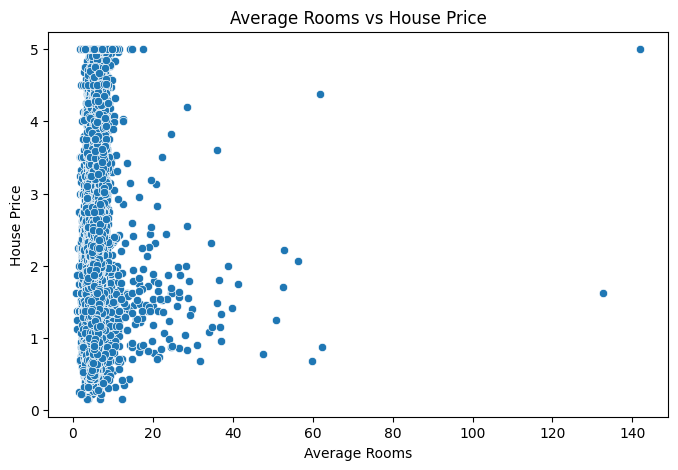

In [59]:
# ============================================================
# BIVARIATE ANALYSIS
# ============================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['AveRooms'],
    y=df['MedHouseVal']
)

plt.title("Average Rooms vs House Price")

plt.xlabel("Average Rooms")

plt.ylabel("House Price")

plt.show()

### Pairplot

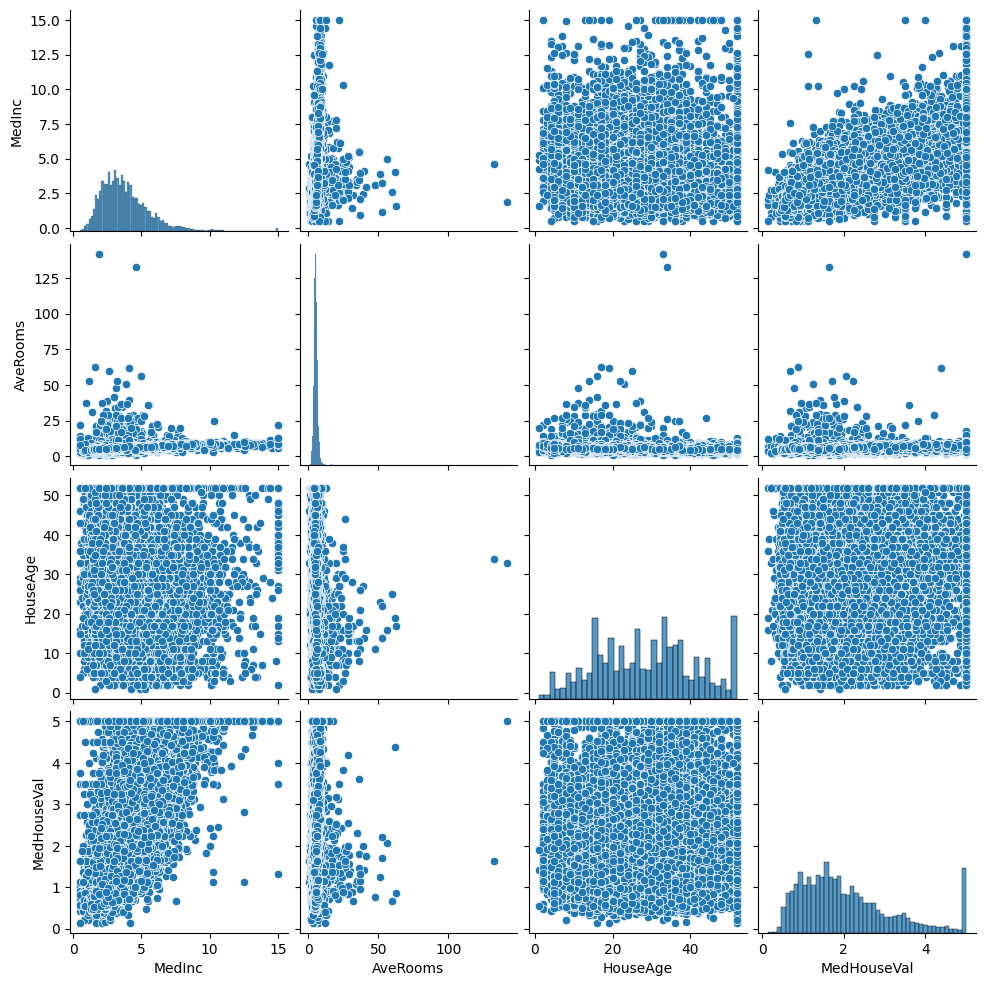

In [60]:
# ============================================================
# PAIRPLOT
# ============================================================

sns.pairplot(
    df[
        [
            'MedInc',
            'AveRooms',
            'HouseAge',
            'MedHouseVal'
        ]
    ]
)

plt.show()


### Skewness Check

In [61]:
# ============================================================
# SKEWNESS ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("SKEWNESS ANALYSIS")
print("=" * 60)

display(df.skew())



SKEWNESS ANALYSIS


MedInc          1.646657
HouseAge        0.060331
AveRooms       20.697869
AveBedrms      31.316956
Population      4.935858
AveOccup       97.639561
Latitude        0.465953
Longitude      -0.297801
MedHouseVal     0.977763
dtype: float64

### Featuring Engineering

In [62]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

# ------------------------------------------------------------
# Create New Feature
# ------------------------------------------------------------

df['RoomsPerPerson'] = (
    df['AveRooms'] / df['Population']
)

print("\nNew Feature Created : RoomsPerPerson")


New Feature Created : RoomsPerPerson


### Feature and Target Selection

In [63]:
# ------------------------------------------------------------
# Feature Variables
# ------------------------------------------------------------

X = df[
    [
        'AveRooms',
        'MedInc',
        'HouseAge',
        'AveBedrms',
        'Population',
        'AveOccup',
        'Latitude',
        'Longitude',
        'RoomsPerPerson'
    ]
]


# ------------------------------------------------------------
# Target Variable
# ------------------------------------------------------------

y = df['MedHouseVal']


### Train Test Split

In [64]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining and Testing Data Created")


Training and Testing Data Created


### Model Buidling

In [65]:
# ============================================================
# MODEL BUILDING
# ============================================================

print("\n" + "=" * 60)
print("LINEAR REGRESSION MODEL")
print("=" * 60)

model = LinearRegression()


LINEAR REGRESSION MODEL


### Model Training

In [66]:
# ============================================================
# MODEL TRAINING
# ============================================================

model.fit(X_train, y_train)

print("\nModel Training Completed")


Model Training Completed


### Model Parameters

In [67]:
# ============================================================
# MODEL PARAMETERS
# ============================================================

print("\nCoefficient Values")
print(model.coef_)

print("\nIntercept")
print(model.intercept_)


Coefficient Values
[-1.22833759e-01  4.48511194e-01  9.73296135e-03  7.86061097e-01
 -2.19656257e-06 -3.52417208e-03 -4.20141719e-01 -4.34052037e-01
 -6.19076713e-02]

Intercept
-37.0566605527055


In [68]:
### Model Prediction

In [69]:
# ============================================================
# MODEL PREDICTION
# ============================================================

predictions = model.predict(X_test)

print("\nPredictions Generated")


Predictions Generated


### Prection Vs Actual Comparision

In [70]:
# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': predictions
})

print("\nActual vs Predicted Values")

display(comparison.head(10))


Actual vs Predicted Values


,Actual Price,Predicted Price
20046,0.47700,0.718648
3024,0.45800,1.764792
15663,5.00001,2.710075
20484,2.18600,2.839108
9814,2.78000,2.605307
13311,1.58700,2.011141
7113,1.98200,2.645917
7668,1.57500,2.168891
18246,3.40000,2.740086
5723,4.46600,3.915742


### Model Evaluation

In [71]:
# ============================================================
# MODEL EVALUATION
# ============================================================

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# Mean Absolute Error
# ------------------------------------------------------------

mae = mean_absolute_error(
    y_test,
    predictions
)

print(f"\nMAE  : {mae}")

# ------------------------------------------------------------
# Mean Squared Error
# ------------------------------------------------------------

mse = mean_squared_error(
    y_test,
    predictions
)

print(f"MSE  : {mse}")

# ------------------------------------------------------------
# Root Mean Squared Error
# ------------------------------------------------------------

rmse = np.sqrt(mse)

print(f"RMSE : {rmse}")


# ------------------------------------------------------------
# R2 Score
# ------------------------------------------------------------

r2 = r2_score(
    y_test,
    predictions
)

print(f"R2 Score : {r2}")


MODEL EVALUATION

MAE  : 0.5331399717607558
MSE  : 0.5555167248646321
RMSE : 0.7453299436253934
R2 Score : 0.5760737799504694


### Prediction Visualization

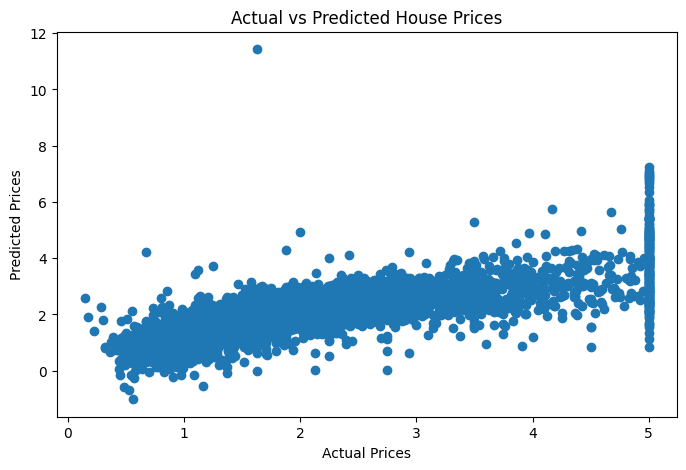

In [72]:
# ============================================================
# VISUALIZE PREDICTIONS
# ============================================================

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

### Feature Analysis

In [73]:
# ============================================================
# FEATURE IMPORTANCE ANALYSIS
# ============================================================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nFeature Importance")

display(
    feature_importance.sort_values(
        by='Coefficient',
        ascending=False
    )
)


Feature Importance


,Feature,Coefficient
3,AveBedrms,0.786061
1,MedInc,0.448511
2,HouseAge,0.009733
4,Population,-0.000002
5,AveOccup,-0.003524
8,RoomsPerPerson,-0.061908
0,AveRooms,-0.122834
6,Latitude,-0.420142
7,Longitude,-0.434052
